## Exercise 7.01: Loading and Understanding the data

### 1.1 import thư viện

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1.2. Đọc file csv và mô tả dataset

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/'\
                 'PacktWorkshops/'\
                 'The-Data-Analysis-Workshop/master/'\
                 'Chapter07/Dataset/heart.csv')


In [8]:
df.describe()
#mục đích của describe() : để hiểu dữ liệu nằm trong range nào, có outlier không, phân bố ra sao

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [10]:
df.rename(index = str, \
          columns = {'cp' : 'chest_pain', \
                     'trestbps' : 'rest_bp', \
                     'fbs' : 'fast_bld_sugar', \
                     'restecg' : 'rest_ecg', \
                     'thalach' : 'max_hr', \
                     'exang' : 'ex_angina', \
                     'oldpeak' : 'st_depr', \
                     'ca' : 'colored_vessels', \
                     'thal' : 'thalassemia', }, inplace = True)


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              303 non-null    int64  
 1   sex              303 non-null    int64  
 2   chest_pain       303 non-null    int64  
 3   rest_bp          303 non-null    int64  
 4   chol             303 non-null    int64  
 5   fast_bld_sugar   303 non-null    int64  
 6   rest_ecg         303 non-null    int64  
 7   max_hr           303 non-null    int64  
 8   ex_angina        303 non-null    int64  
 9   st_depr          303 non-null    float64
 10  slope            303 non-null    int64  
 11  colored_vessels  303 non-null    int64  
 12  thalassemia      303 non-null    int64  
 13  target           303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.5+ KB


Đây là bước hiểu nội dung :
- Ở dữ liệu này, chúng ta có thể thấy có 303 mẫu với 14 đặc trưng và tất cả đăc trưng thuộc loại biến số (numeric) và biến mục tiêu là biến phân loại binary.

- age: tuổi
- sex: giới tính
- cp : đau ngực (4 loại)
- trestbps : huyết áp
- chol: cholesterol - huyết thanh 
- fbs : đường huyết lúc đói có lớn hơn 120mg/dl
- restecg : điện tâm đồ lúc nghỉ (3 loại)
- thalach : nhịp tim
- exang : đau thắt ngực khi gắng sức 
- oldpeak : mức chênh xuống của đoạn ST do gắng sức so với trạng thái nghỉ 
- slope : độ dốc đoạn ST ở mức gắng sức cao nhất (3 loại )
- ca : số lượng máu lớn được nhuộm màu bằng phương pháp huỳnh quang
- thal : bệnh tan máu bẩm sinh 


In [12]:
df.isnull().sum()

age                0
sex                0
chest_pain         0
rest_bp            0
chol               0
fast_bld_sugar     0
rest_ecg           0
max_hr             0
ex_angina          0
st_depr            0
slope              0
colored_vessels    0
thalassemia        0
target             0
dtype: int64

đa phần bộ dữ liệu này không có giá trị null


In [13]:
print(df.duplicated().sum())
df[df.duplicated(keep=False)]


1


,age,sex,chest_pain,rest_bp,chol,fast_bld_sugar,rest_ecg,max_hr,ex_angina,st_depr,slope,colored_vessels,thalassemia,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [14]:
df.drop_duplicates(inplace = True)

df[df.duplicated(keep=False)]

,age,sex,chest_pain,rest_bp,chol,fast_bld_sugar,rest_ecg,max_hr,ex_angina,st_depr,slope,colored_vessels,thalassemia,target


In [15]:
continuous = []
discrete = []

for i in df.columns: 
    if df[i].nunique() < 10:
        discrete.append(i)
    else: 
        continuous.append(i)
        
print("Continuous: ", continuous)
print("Discrete: ", discrete)

Continuous:  ['age', 'rest_bp', 'chol', 'max_hr', 'st_depr']
Discrete:  ['sex', 'chest_pain', 'fast_bld_sugar', 'rest_ecg', 'ex_angina', 'slope', 'colored_vessels', 'thalassemia', 'target']


- Biến liên tục (Continuous Variable): nhận các giá trị trong 1 khoảng liên tục như đo lường (measurement), số thực, số thập phân,..
=> thường sủ dụng biểu đồ histogram, boxplot
- Biến rời rạc (Discrete Variable) : nhận các giá trị có thể đếm được, hoặc có thể phân loại như 0 và 1 => thường sử dụng biểu đồ countplot
    - giới tính (0,1)
    - loại đau ngực (0,1,2,3)
    - số mạch máu (0,1,2,3,4)
    - target (0,1)

- Binary => bar chart

## Exercise 7.02: Checking for outliers

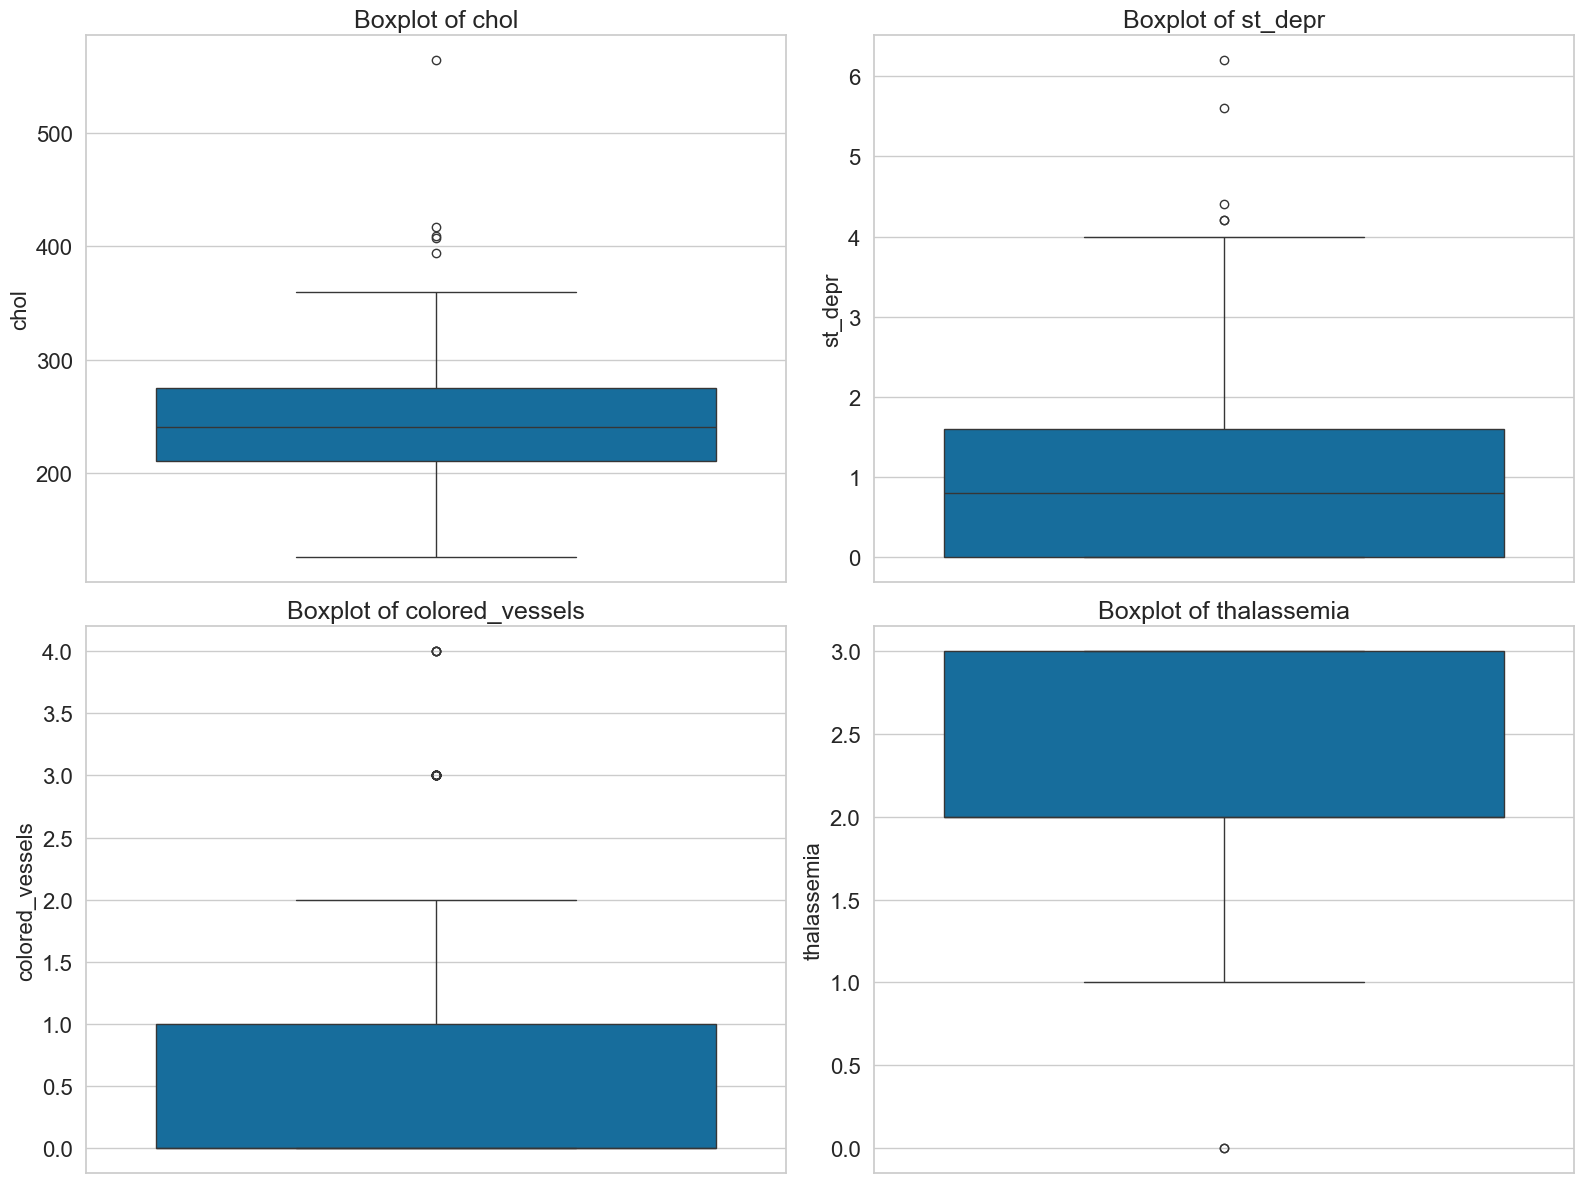

In [16]:
fts_outliers =  ['chol', 'st_depr', 'colored_vessels', 'thalassemia']

figs, axes = plt.subplots(2, 2, figsize = (16,12))

for i, col in enumerate(fts_outliers):
    sns.boxplot(df[col], ax = axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Boxplot of {col}', fontsize = 18)

# sns.set(palette = 'pastel', rc = {"figure.figsize": (12,8), \
#                                   "axes.titlesize" : 18, \
# "axes.labelsize" : 16, \
# "xtick.labelsize" : 16, \
# "ytick.labelsize" : 16 })

# chol = sns.boxplot(df['chol'])
plt.tight_layout()
plt.show()


## Exercise 7.03: Plotting the distributions & relationships between specific features

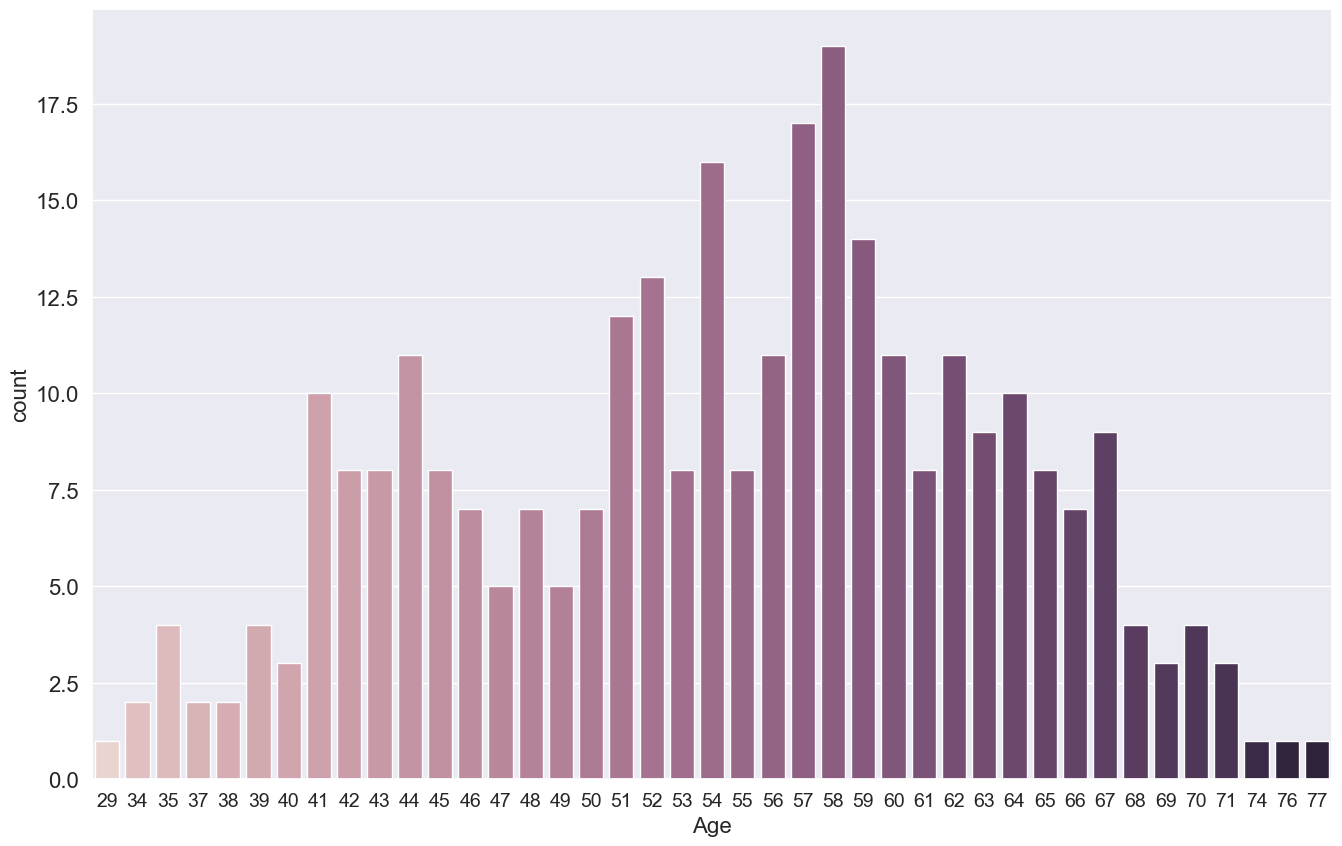

In [17]:
sns.set(palette = 'pastel', rc = {"figure.figsize": (16,10), \
                                  "axes.titlesize" : 18, \
"axes.labelsize" : 16, \
"xtick.labelsize" : 14, \
"ytick.labelsize" : 16 })


g = sns.countplot(x = 'age', data = df, hue = 'age', legend = False)
plt.xlabel('Age')

plt.show()

In [18]:
df.target.value_counts()

target
1    164
0    138
Name: count, dtype: int64

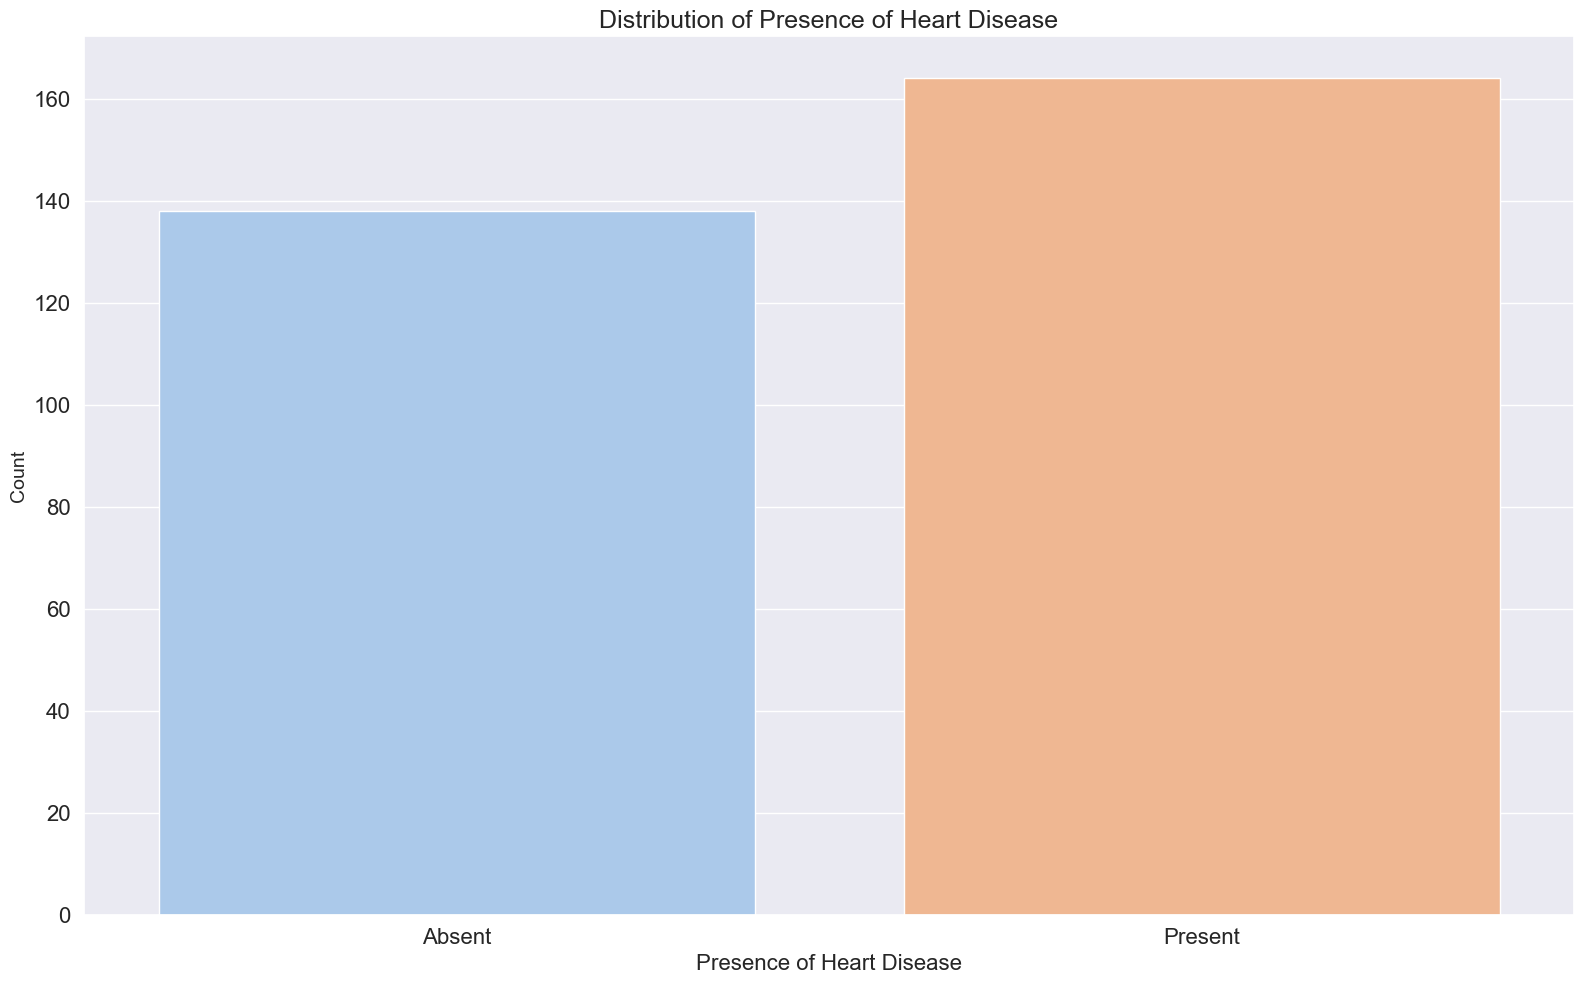

In [19]:
a = sns.countplot(x = 'target', data = df, hue= 'target', palette='pastel', legend = False)

a.set_title('Distribution of Presence of Heart Disease')
a.set_xticks([0, 1])
a.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.xlabel("Presence of Heart Disease", fontsize = 16)
plt.ylabel("Count", fontsize = 14)

plt.tight_layout()
plt.show()


In [20]:
df.sex.value_counts()

sex
1    206
0     96
Name: count, dtype: int64

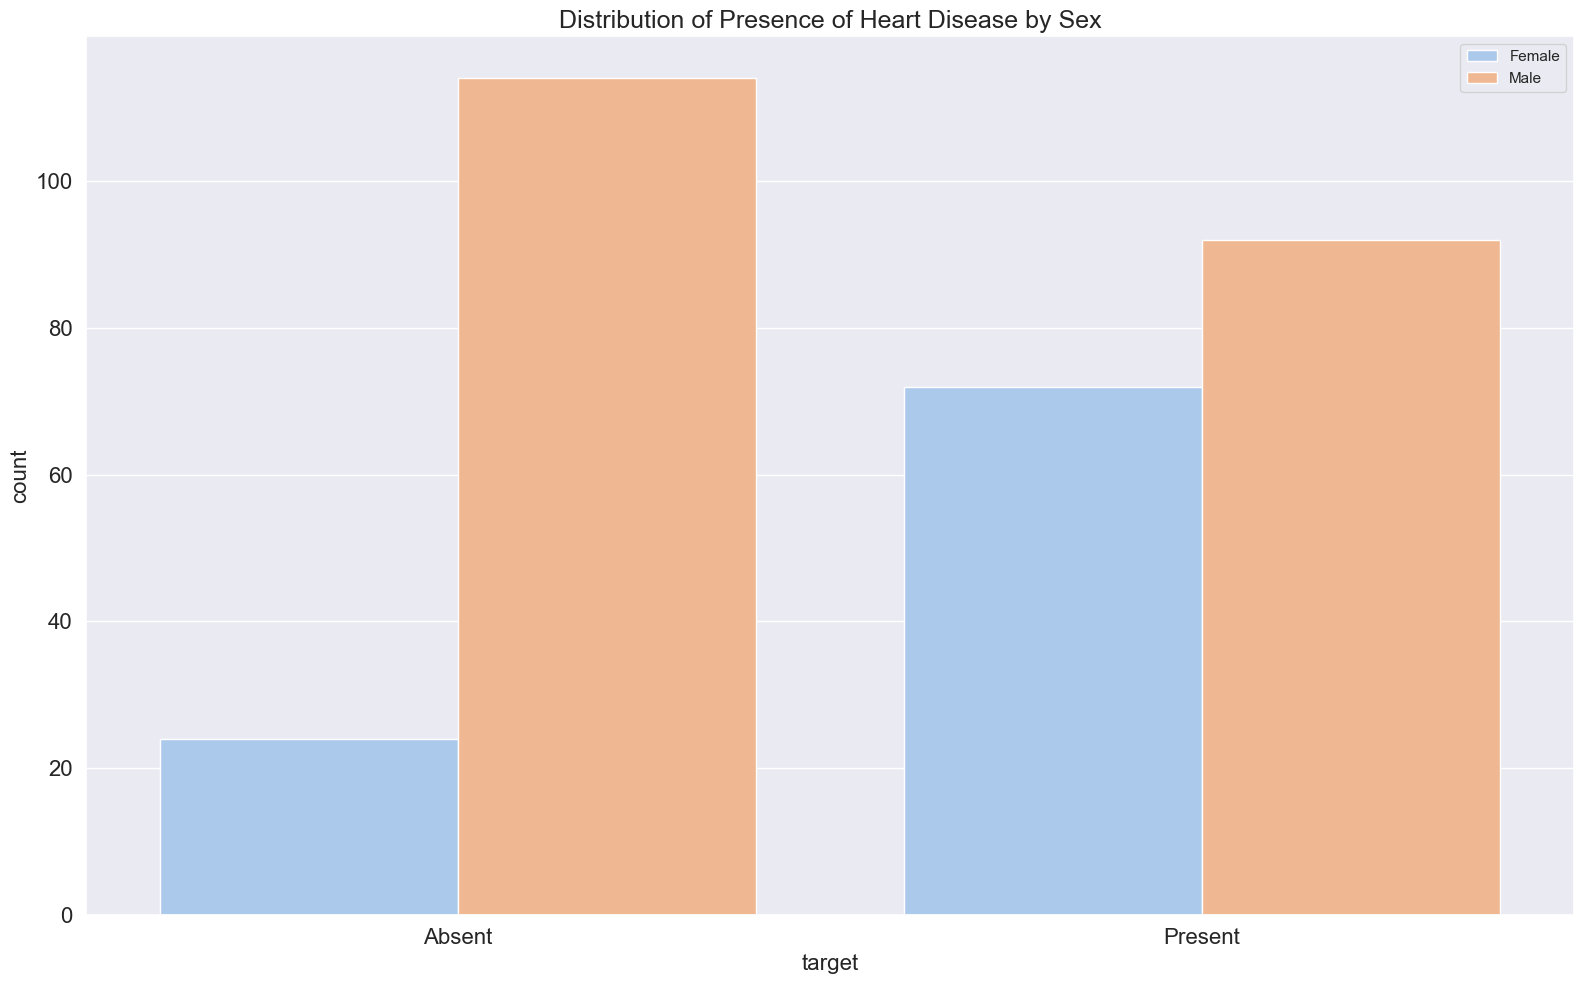

In [21]:
b = sns.countplot(x = 'target', data = df, hue = 'sex', palette='pastel', legend = False)

b.set_title('Distribution of Presence of Heart Disease by Sex')

b.set_xticks([0, 1])
b.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.legend(labels=['Female', 'Male'])
plt.tight_layout()
plt.show()


### Activity 7.02: Plotting Distributions and Relationships between Columns with
Respect to the Target Colum

In [22]:
df.chest_pain.value_counts()

chest_pain
0    143
2     86
1     50
3     23
Name: count, dtype: int64

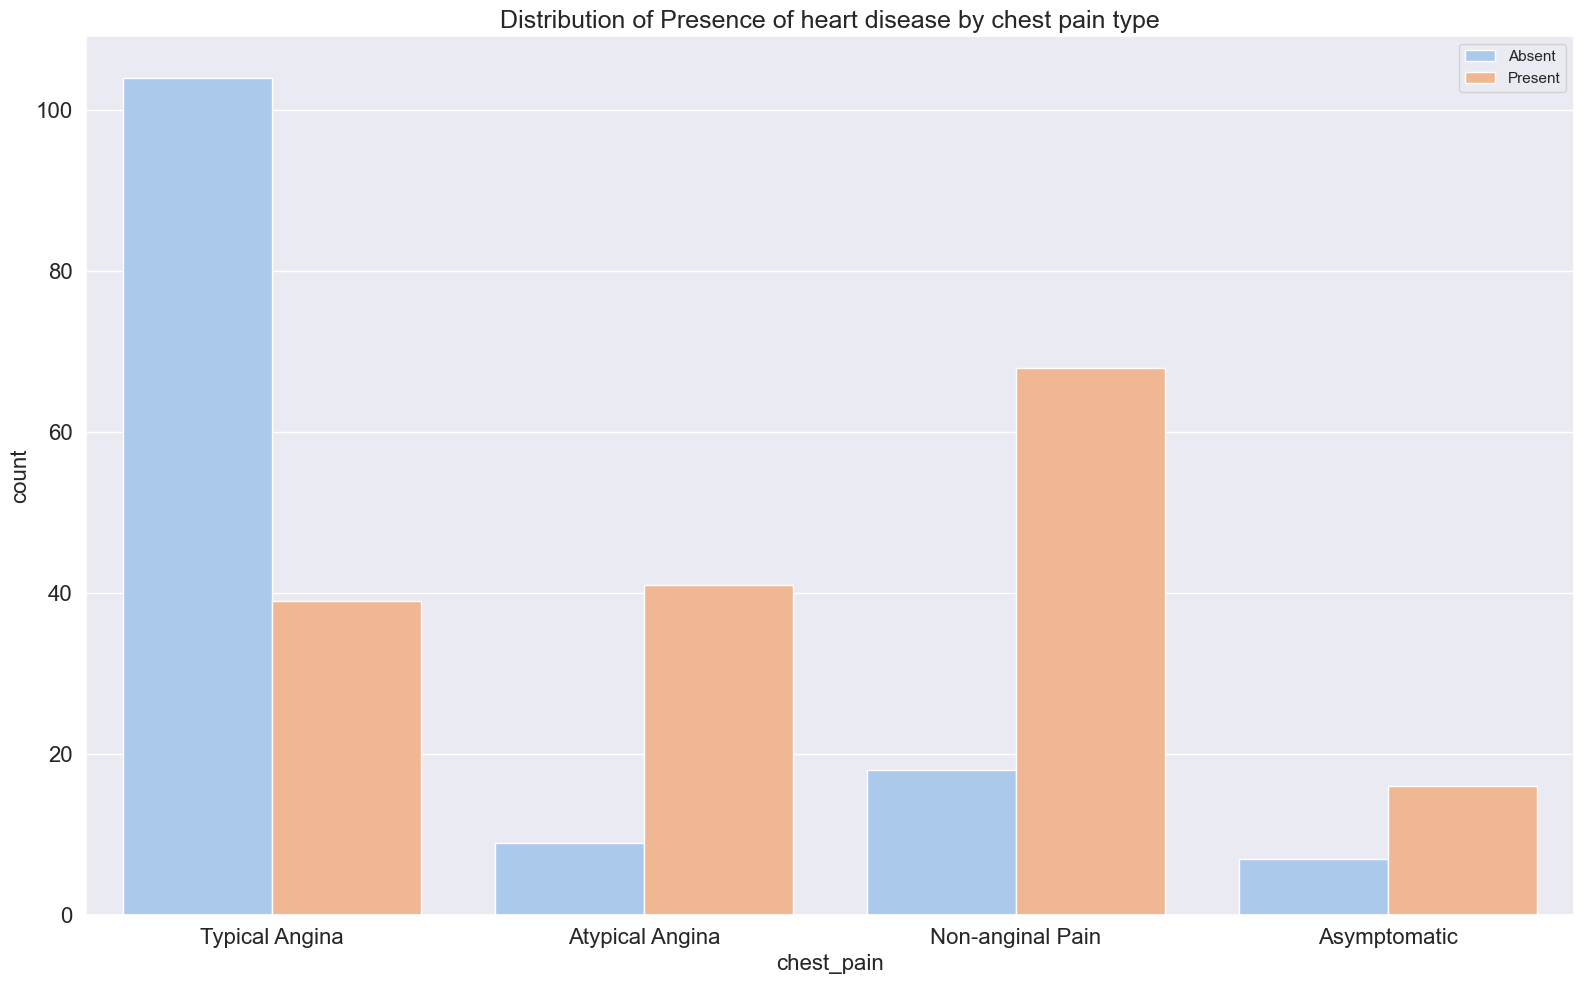

In [23]:
c = sns.countplot(x = 'chest_pain', data = df, hue = 'target', palette='pastel', legend = False)

c.set_title('Distribution of Presence of heart disease by chest pain type')
c.set_xticks([0, 1, 2, 3])
c.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()

In [24]:
df.colored_vessels.value_counts()

colored_vessels
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

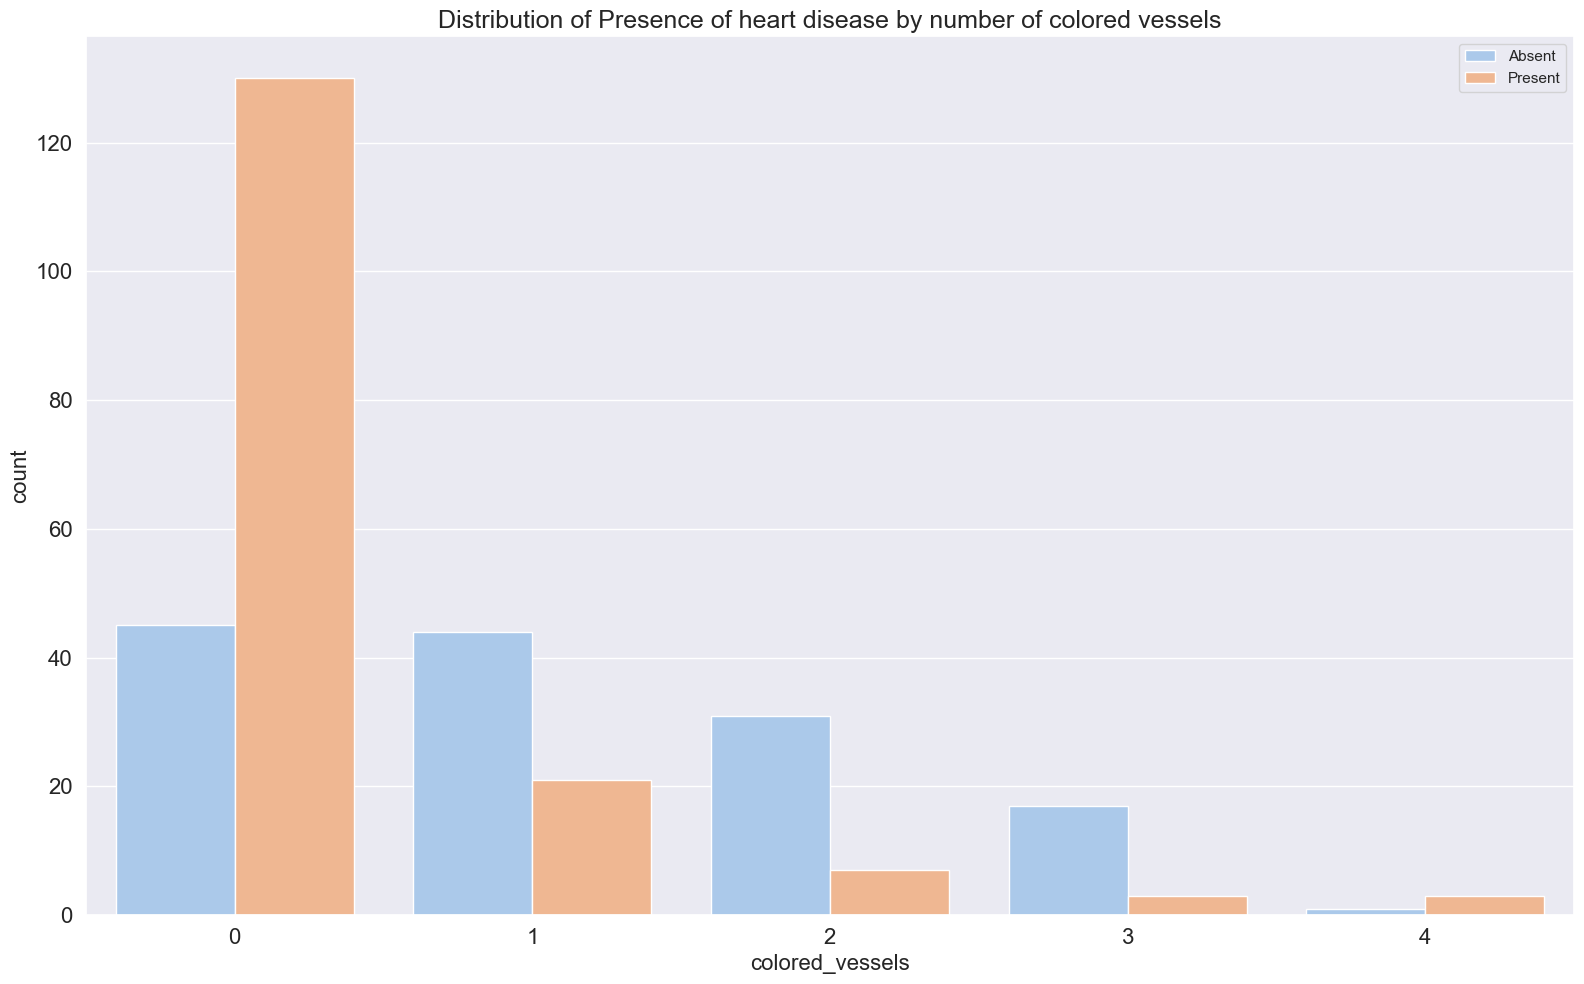

In [25]:
d = sns.countplot(x = 'colored_vessels', data= df, hue='target', palette='pastel', legend = False)
d.set_title('Distribution of Presence of heart disease by number of colored vessels')
d.set_xticks([0, 1, 2, 3, 4])
d.set_xticklabels(['0', '1', '2', '3', '4'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()

In [26]:
df.slope.value_counts()

slope
2    141
1    140
0     21
Name: count, dtype: int64

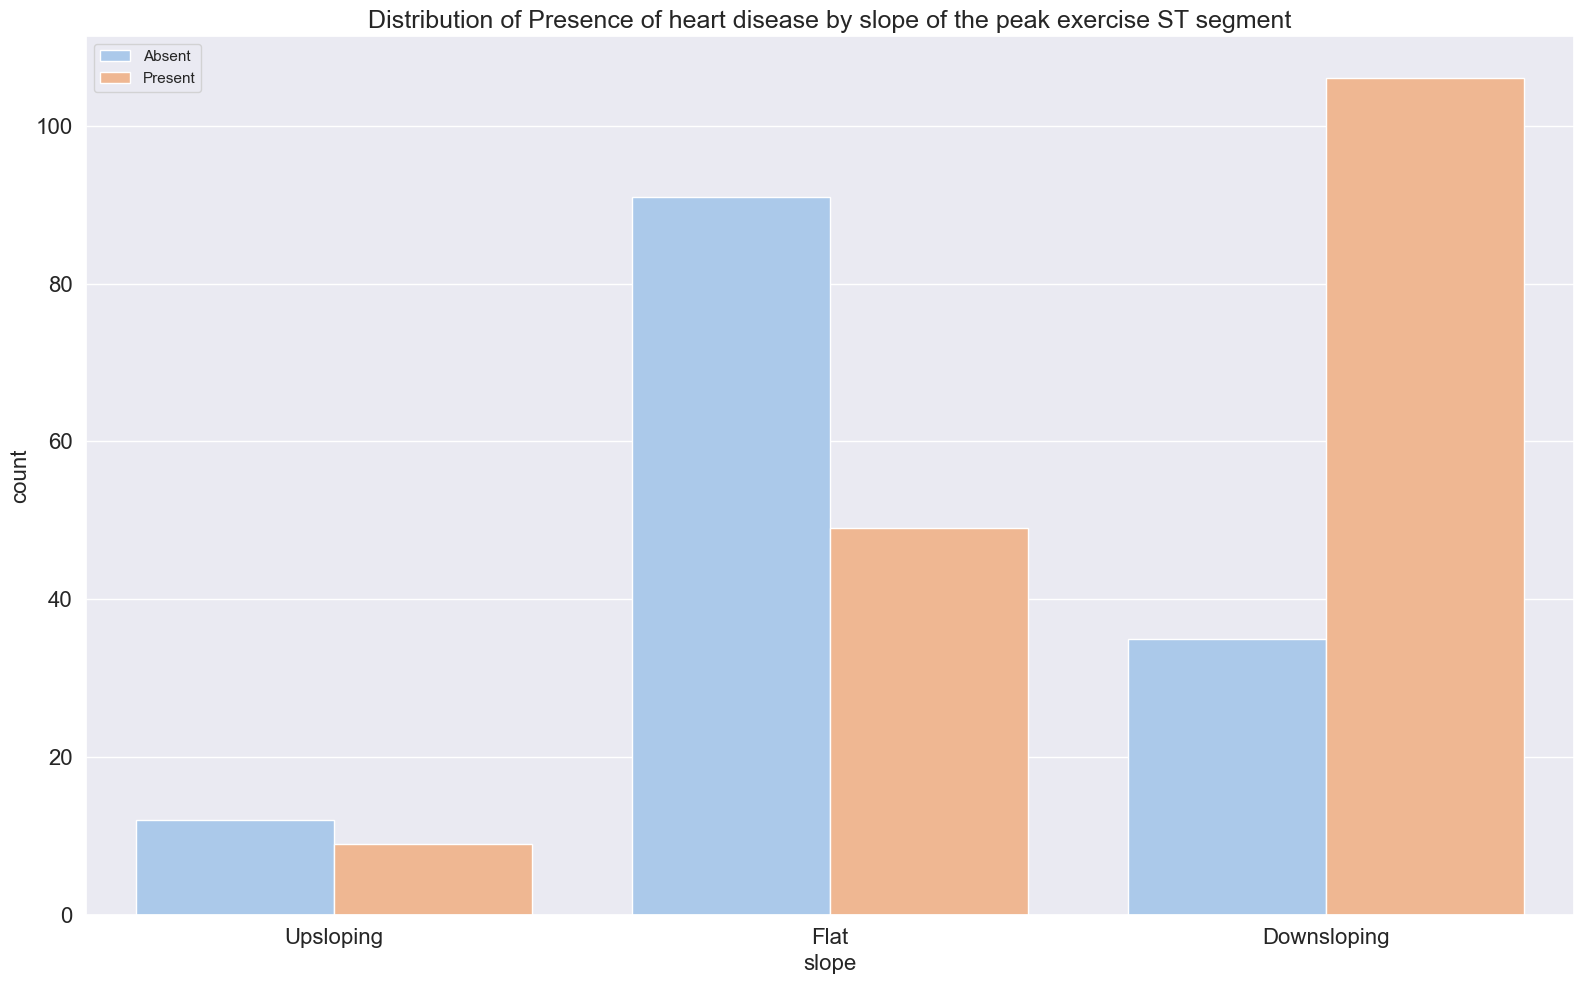

In [27]:
e = sns.countplot(x = 'slope', data = df, hue = 'target', palette='pastel', legend = False)
e.set_title('Distribution of Presence of heart disease by slope of the peak exercise ST segment')
e.set_xticks([0, 1, 2])
e.set_xticklabels(['Upsloping', 'Flat', 'Downsloping'], fontsize = 16)
plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()  
plt.show()

## Exercise 7.04: Plotting the Relationship between the Presence of Heart Disease
and Maximum Recorded Heart Rate

Text(0, 0.5, 'Maximum Heart Rate')

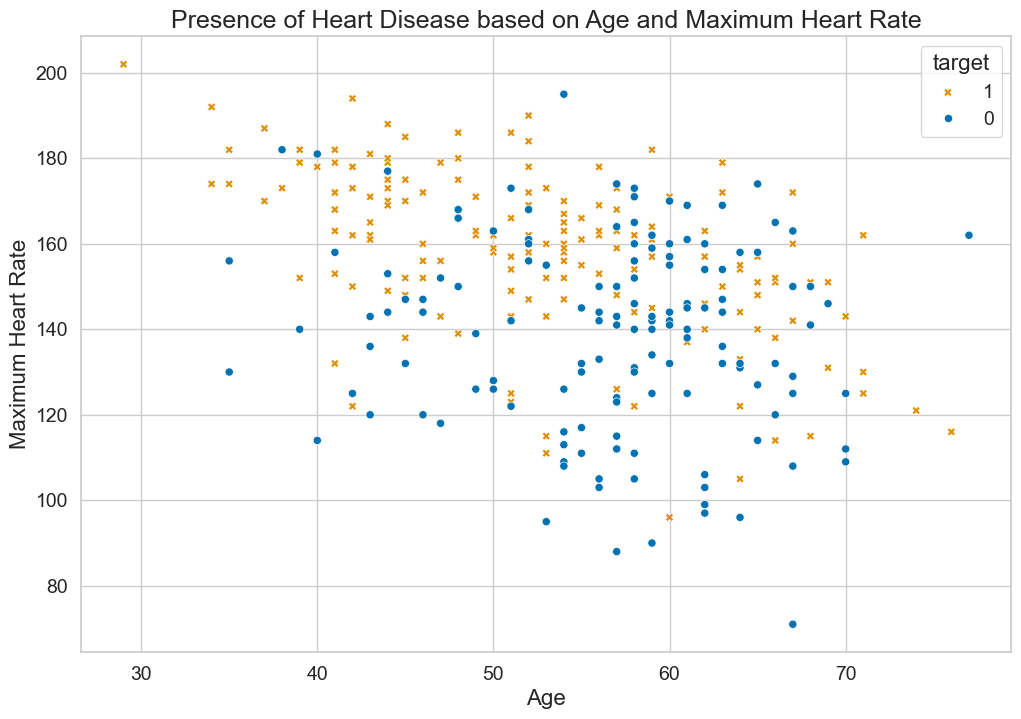

In [34]:
sns.set(style = 'whitegrid', palette = 'colorblind', rc = {"figure.figsize": (12,8), "axes.titlesize" : 18, \
        "axes.labelsize" : 16, "xtick.labelsize" : 16, \
        "ytick.labelsize" : 16 }
)

f = sns.scatterplot(x = 'age', y ='max_hr', hue='target', style='target',data=df, palette= 'colorblind', s=35)
f.set_title('Presence of Heart Disease based on Age and '\
            'Maximum Heart Rate')

f.legend(title='target', labels=["1", "0"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')

Text(0, 0.5, 'Count')

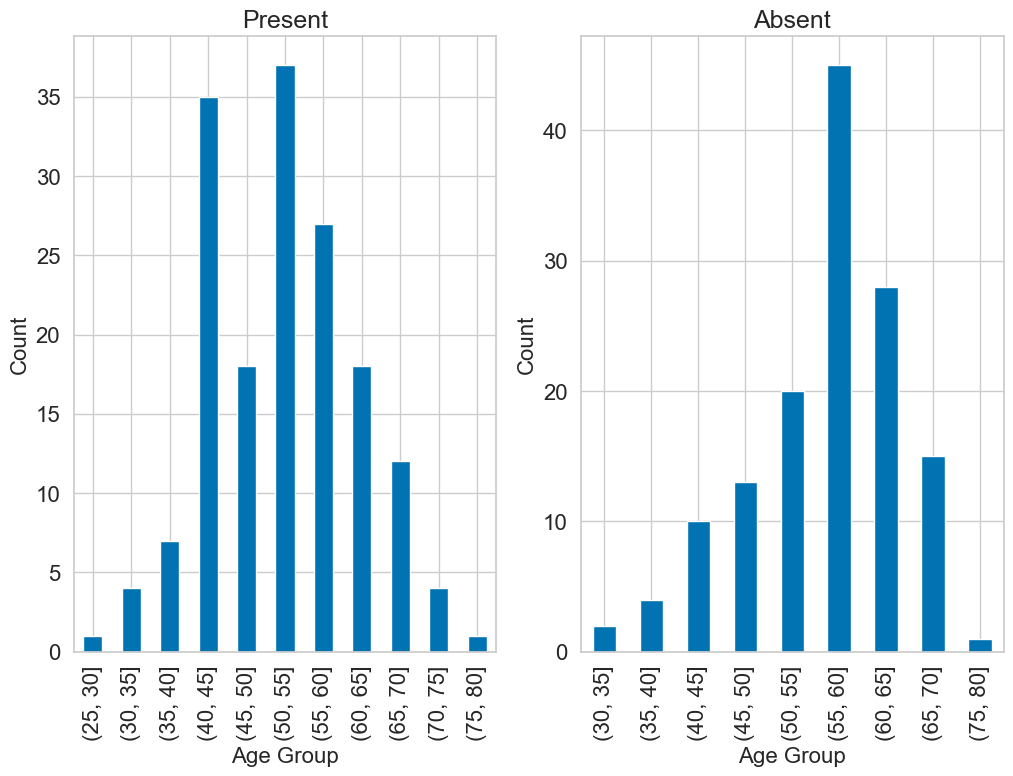

In [29]:

df['age_category'] = pd.cut(df.age, \
                            bins = list(np.arange(25, 85, 5)))

plt.subplot(121)
df[df.target == 1].groupby('age_category')['age']\
                    .count().plot(kind = 'bar')
                    
plt.title('Present')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('age_category')['age']\
.count().plot(kind = 'bar')

plt.title('Absent')
plt.xlabel('Age Group')
plt.ylabel('Count')



### Activity 7.03: Plotting the Relationship between the Presence of Heart Disease
and the Cholesterol Column

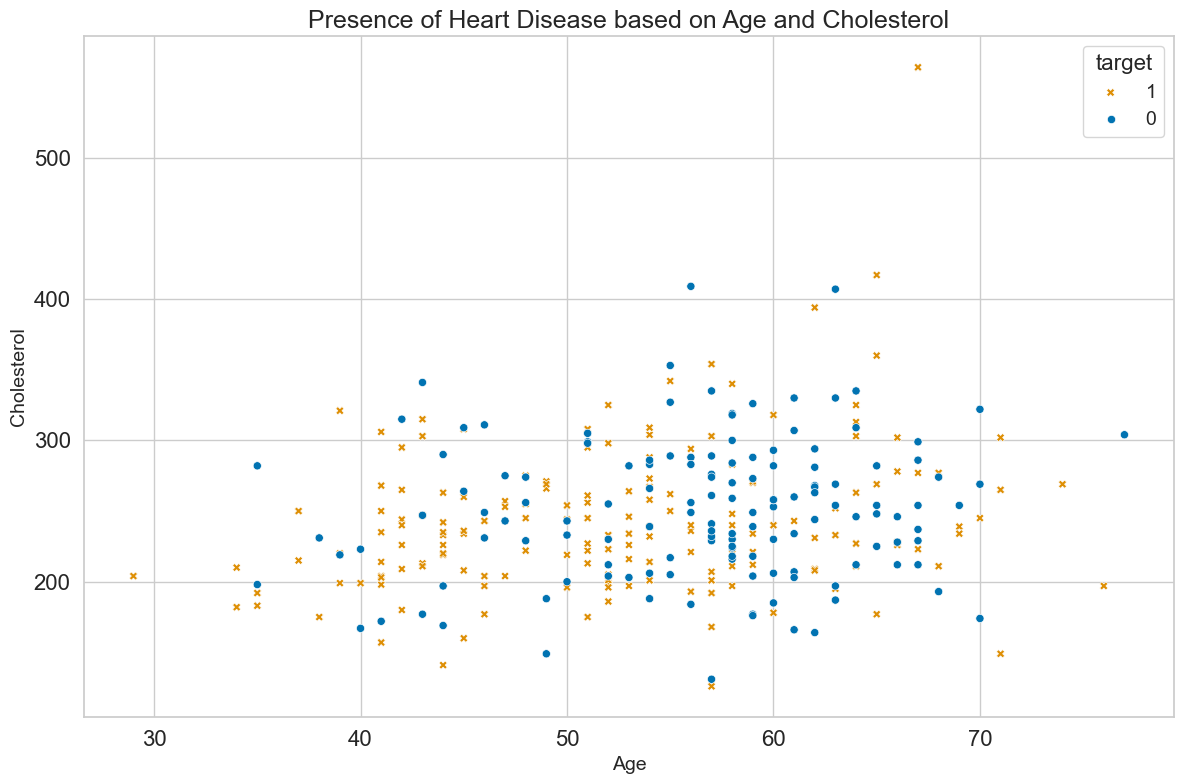

In [35]:
g = sns.scatterplot(x = 'age', y ='chol', hue ='target', style = 'target', data = df, palette = 'colorblind', s = 35)
g.set_title("Presence of Heart Disease based on Age and Cholesterol")

plt.xlabel('Age', fontsize = 14)
plt.ylabel('Cholesterol', fontsize = 14)
g.legend(title = 'target', labels = ["1", "0"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

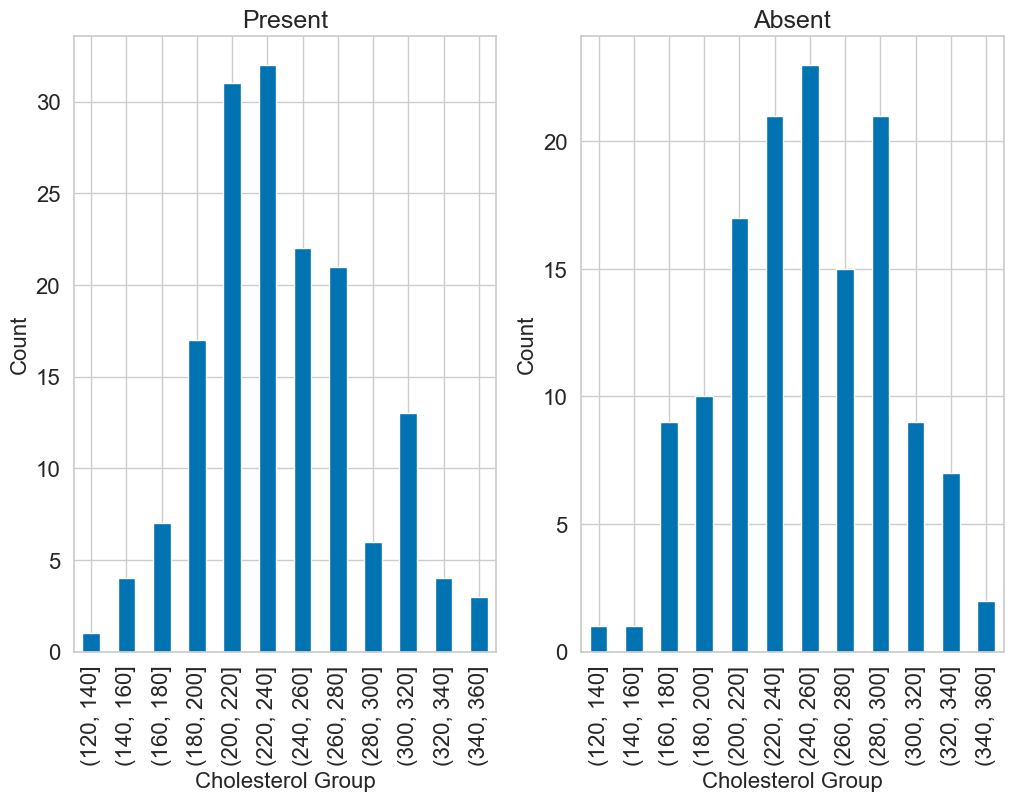

In [31]:
df['chol_category'] = pd.cut(df.chol, bins = list(np.arange(120, 380, 20)))

#plt.figure(figsize=(10,5))
plt.subplot(121)
df[df.target == 1].groupby('chol_category')['chol']\
                    .count().plot(kind = 'bar')
plt.title('Present')
plt.xlabel('Cholesterol Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('chol_category')['chol']\
.count().plot(kind = 'bar')
plt.title('Absent') 
plt.xlabel('Cholesterol Group')
plt.ylabel('Count')


## Exercise 7.05: Observing Correlations with a Heatmap

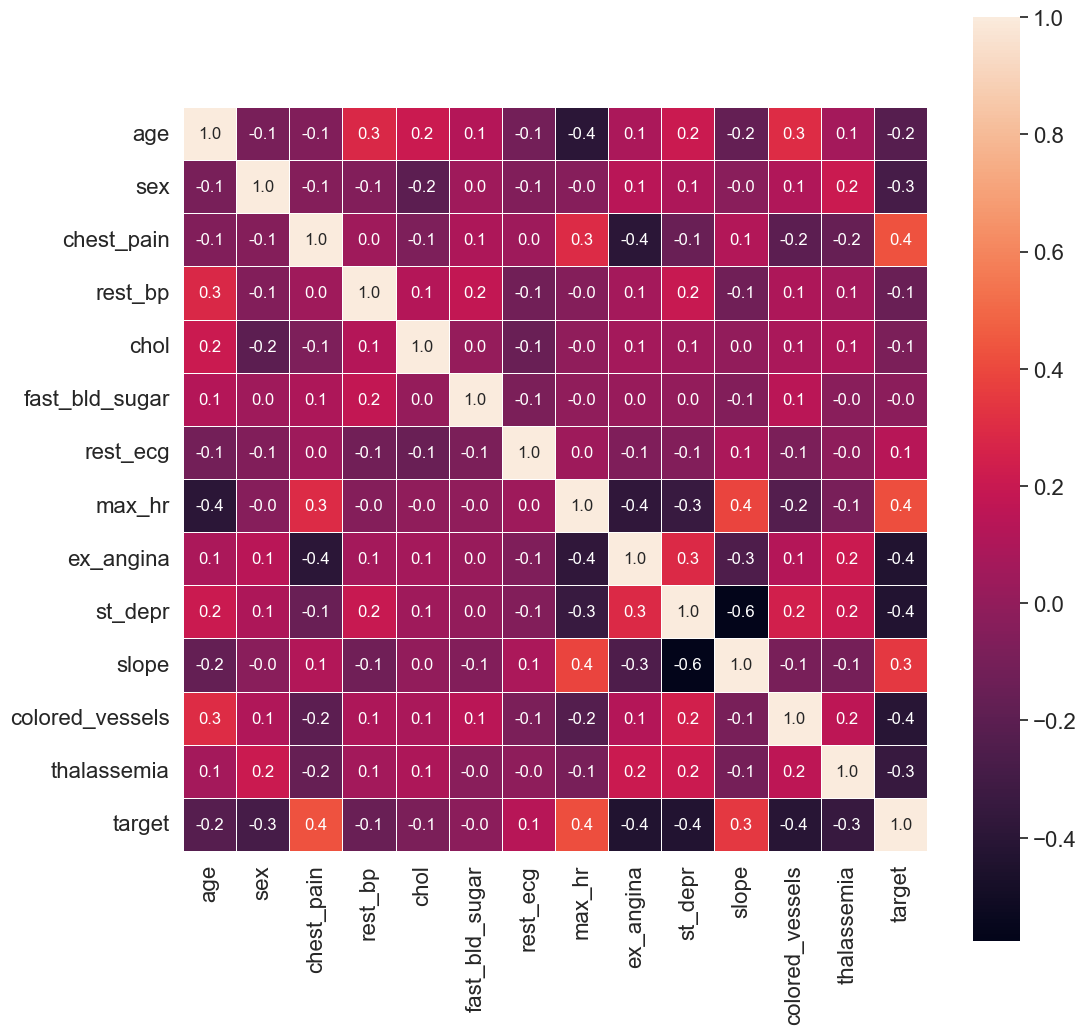

In [40]:
cols = [
    'age', 'sex', 'chest_pain', 'rest_bp', 'chol',
    'fast_bld_sugar', 'rest_ecg', 'max_hr',
    'ex_angina', 'st_depr', 'slope',
    'colored_vessels', 'thalassemia', 'target'
]

corr = df[cols].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True,fmt=".1f", linewidths=0.5, cmap="rocket", square=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()